# 01. Exploratory Data Analysis (EDA)
**Membuktikan Sebab-Akibat dalam Kesehatan: Estimasi Efek Kausal dari Data Observasional**

Fase 1 dari analisis kausal berfokus pada pemahaman dataset Right Heart Catheterization (RHC). 
Tujuan dari notebook ini adalah:
1. Mengunduh dan memuat dataset SUPPORT (Connors et al., 1996).
2. Memeriksa distribusi variabel intervensi (*Treatment*) dan hasil (*Outcome*).
3. Melakukan identifikasi awal terhadap kovariat (*Confounders*).
4. Menganalisis ketidakseimbangan awal kovariat (*Covariate Balance*) menggunakan *Standardized Mean Difference* (SMD).


In [1]:
# Import libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display

# Add src to python path to import our modules
sys.path.append(os.path.abspath('../src'))
from data_loader import download_data, load_and_preprocess_data
from eda import run_eda


## 1. Memuat Dataset

In [2]:
# Download and preprocess data
raw_path = download_data(raw_data_dir="../data/raw")
df = load_and_preprocess_data(raw_path, processed_data_dir="../data/processed")
df.head()


RHC dataset already exists at ../data/raw\rhc.csv
Loading data from ../data/raw\rhc.csv...


Processed dataset saved to ../data/processed\rhc_processed.csv
Dataset shape: (5735, 65)
Treatment distribution:
treatment
0    3551
1    2184
Name: count, dtype: int64
Outcome distribution:
outcome
1    3722
0    2013
Name: count, dtype: int64


,Unnamed: 0,cat1,cat2,ca,sadmdte,dschdte,dthdte,lstctdte,death,cardiohx,...,seps,trauma,ortho,adld3p,urin1,race,income,ptid,treatment,outcome
0,1,COPD,NaN,Yes,11142,11151.0,NaN,11382,No,0,...,No,No,No,0.0,NaN,white,Under $11k,5,0,0
1,2,MOSF w/Sepsis,NaN,No,11799,11844.0,11844.0,11844,Yes,1,...,Yes,No,No,NaN,1437.0,white,Under $11k,7,1,1
2,3,MOSF w/Malignancy,MOSF w/Sepsis,Yes,12083,12143.0,NaN,12400,No,0,...,No,No,No,NaN,599.0,white,$25-$50k,9,1,0
3,4,ARF,NaN,No,11146,11183.0,11183.0,11182,Yes,0,...,No,No,No,NaN,NaN,white,$11-$25k,10,0,1
4,5,MOSF w/Sepsis,NaN,No,12035,12037.0,12037.0,12036,Yes,0,...,No,No,No,NaN,64.0,white,Under $11k,11,1,1


## 2. Karakteristik Data & Missing Values

In [3]:
# Check shape and general info
print(f"Shape of dataset: {df.shape}")
print("\nMissing values count:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Shape of dataset: (5735, 65)

Missing values count:
cat2       4535
dschdte       1
dthdte     2013
adld3p     4296
urin1      3028
dtype: int64


## 3. Eksekusi Analisis EDA & Keseimbangan Kovariat

In [4]:
# Run full EDA workflow (generates plots and report)
# Note: we execute this from the project root perspective (we are in notebooks/ directory, so we adjust paths if needed)
# Since we import eda directly, we can run it
run_eda()


Running EDA...


Treatment distribution plot saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\reports\figures\01_treatment_distribution.png


Outcome by treatment plot saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\reports\figures\02_outcome_by_treatment.png


Love plot saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\reports\figures\03_love_plot_unadjusted.png
Encoded dataset (for modeling) saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\data\processed\rhc_encoded.csv
EDA Summary Report saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\reports\results.md


### Visualisasi Hasil EDA

Di bawah ini adalah visualisasi distribusi treatment, tingkat mortalitas naif, dan Love Plot dari keseimbangan kovariat awal sebelum disesuaikan (*unadjusted*).


--- 1. Distribusi Treatment (RHC) ---


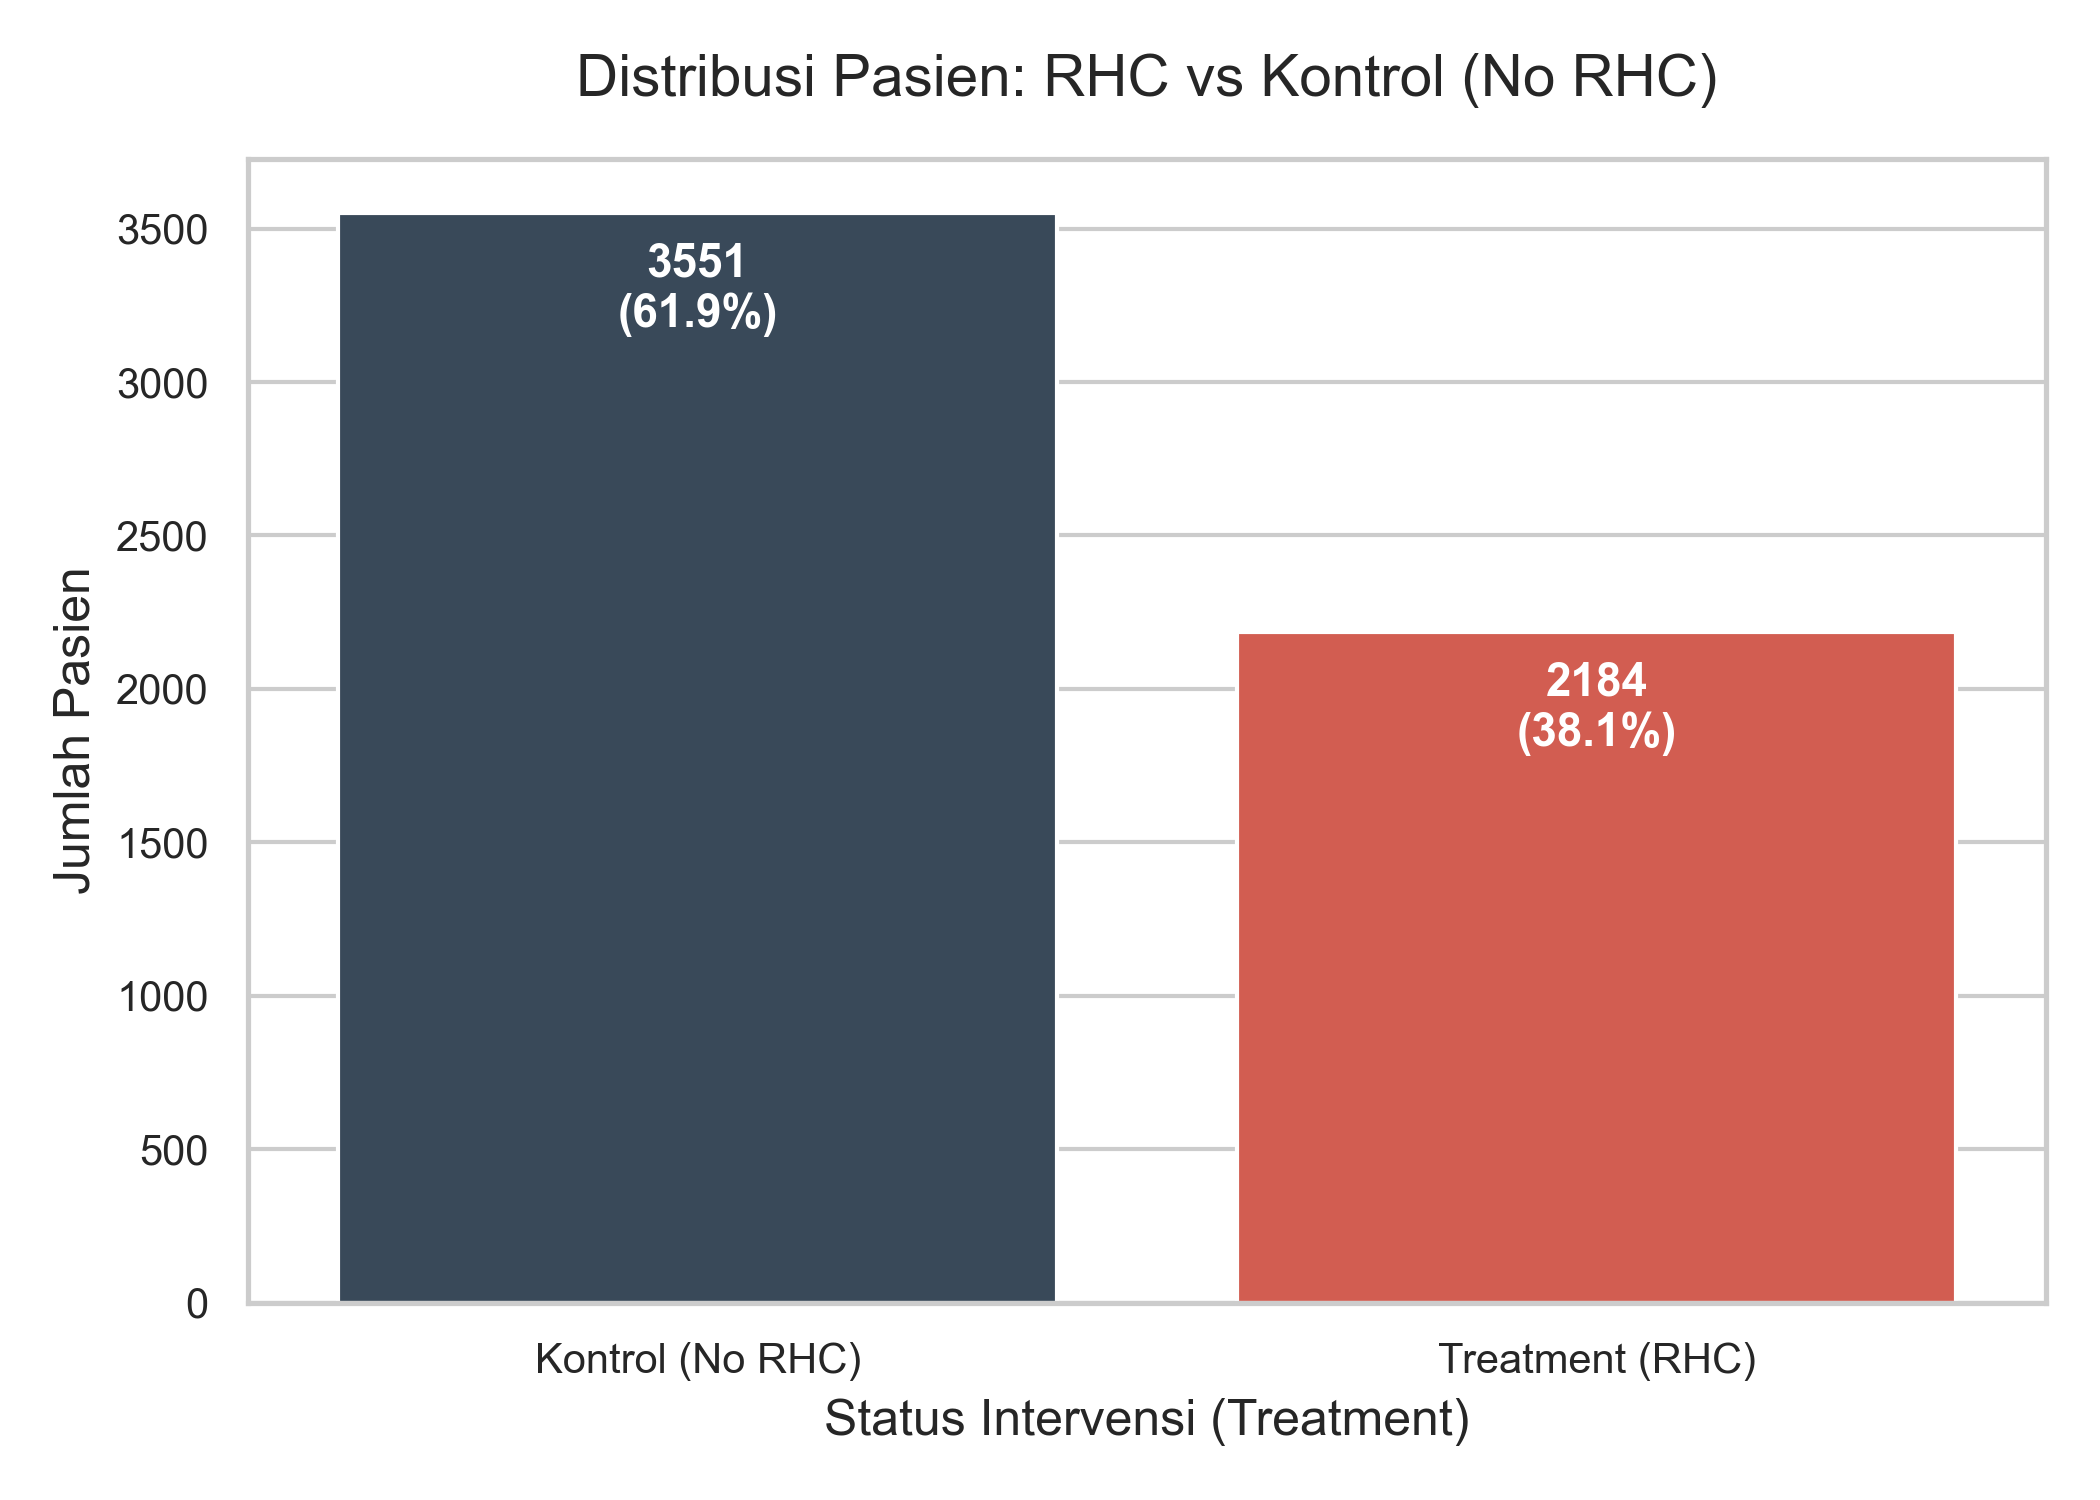


--- 2. Tingkat Mortalitas Naif (Outcome by Treatment) ---


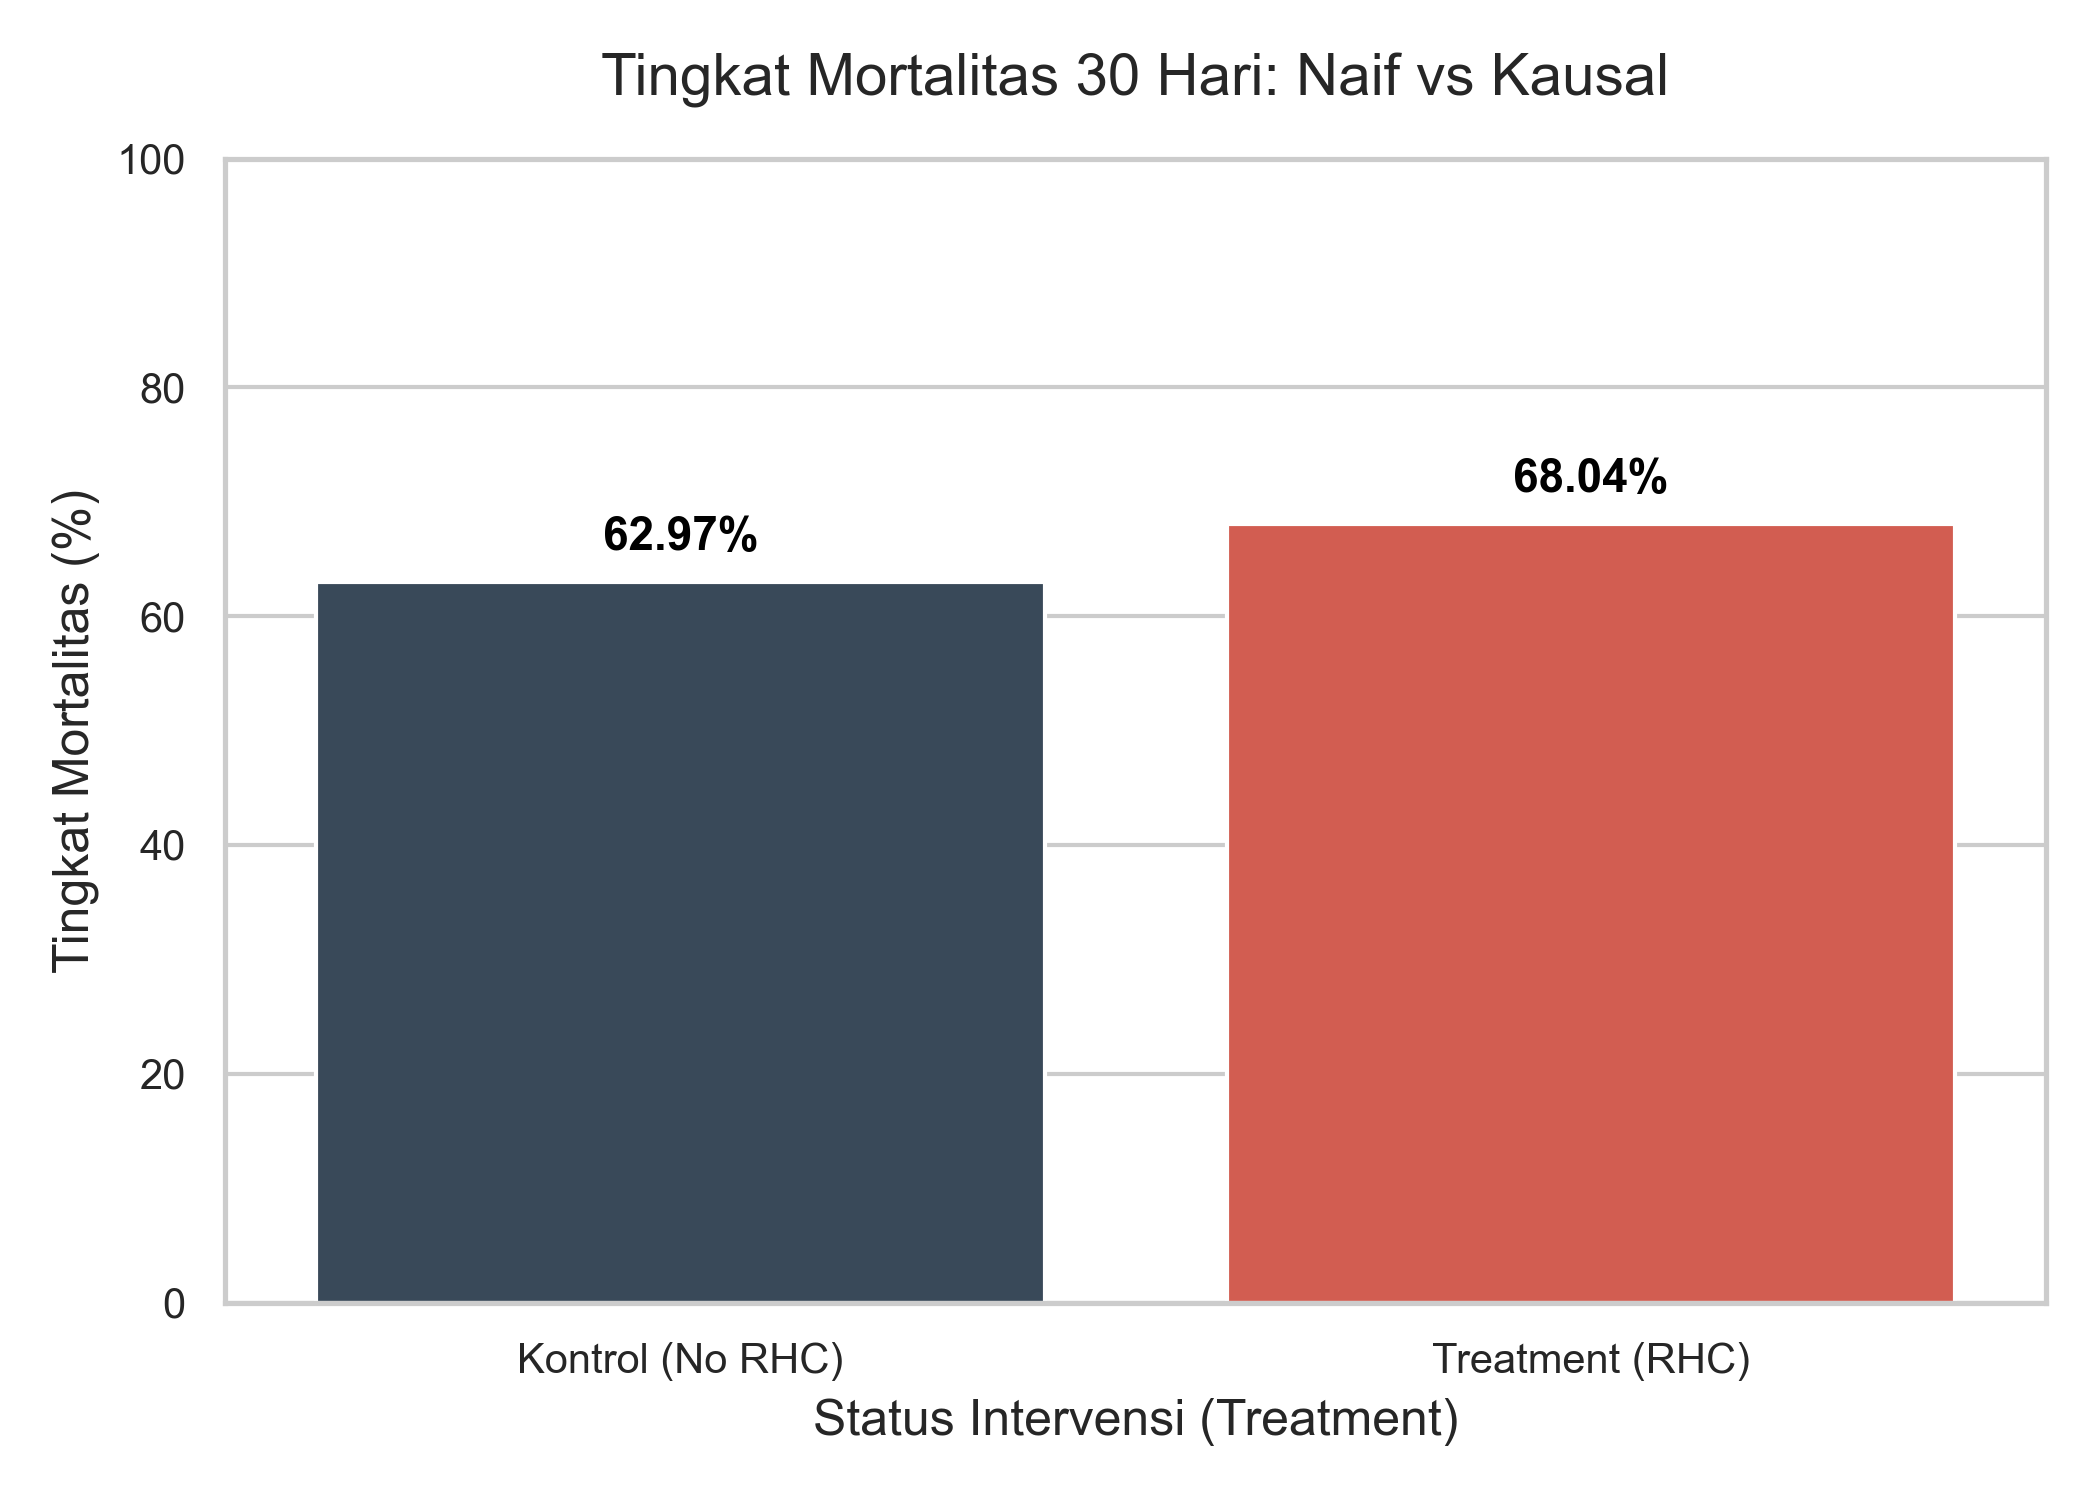


--- 3. Love Plot (Covariate Balance Sebelum Penyesuaian) ---


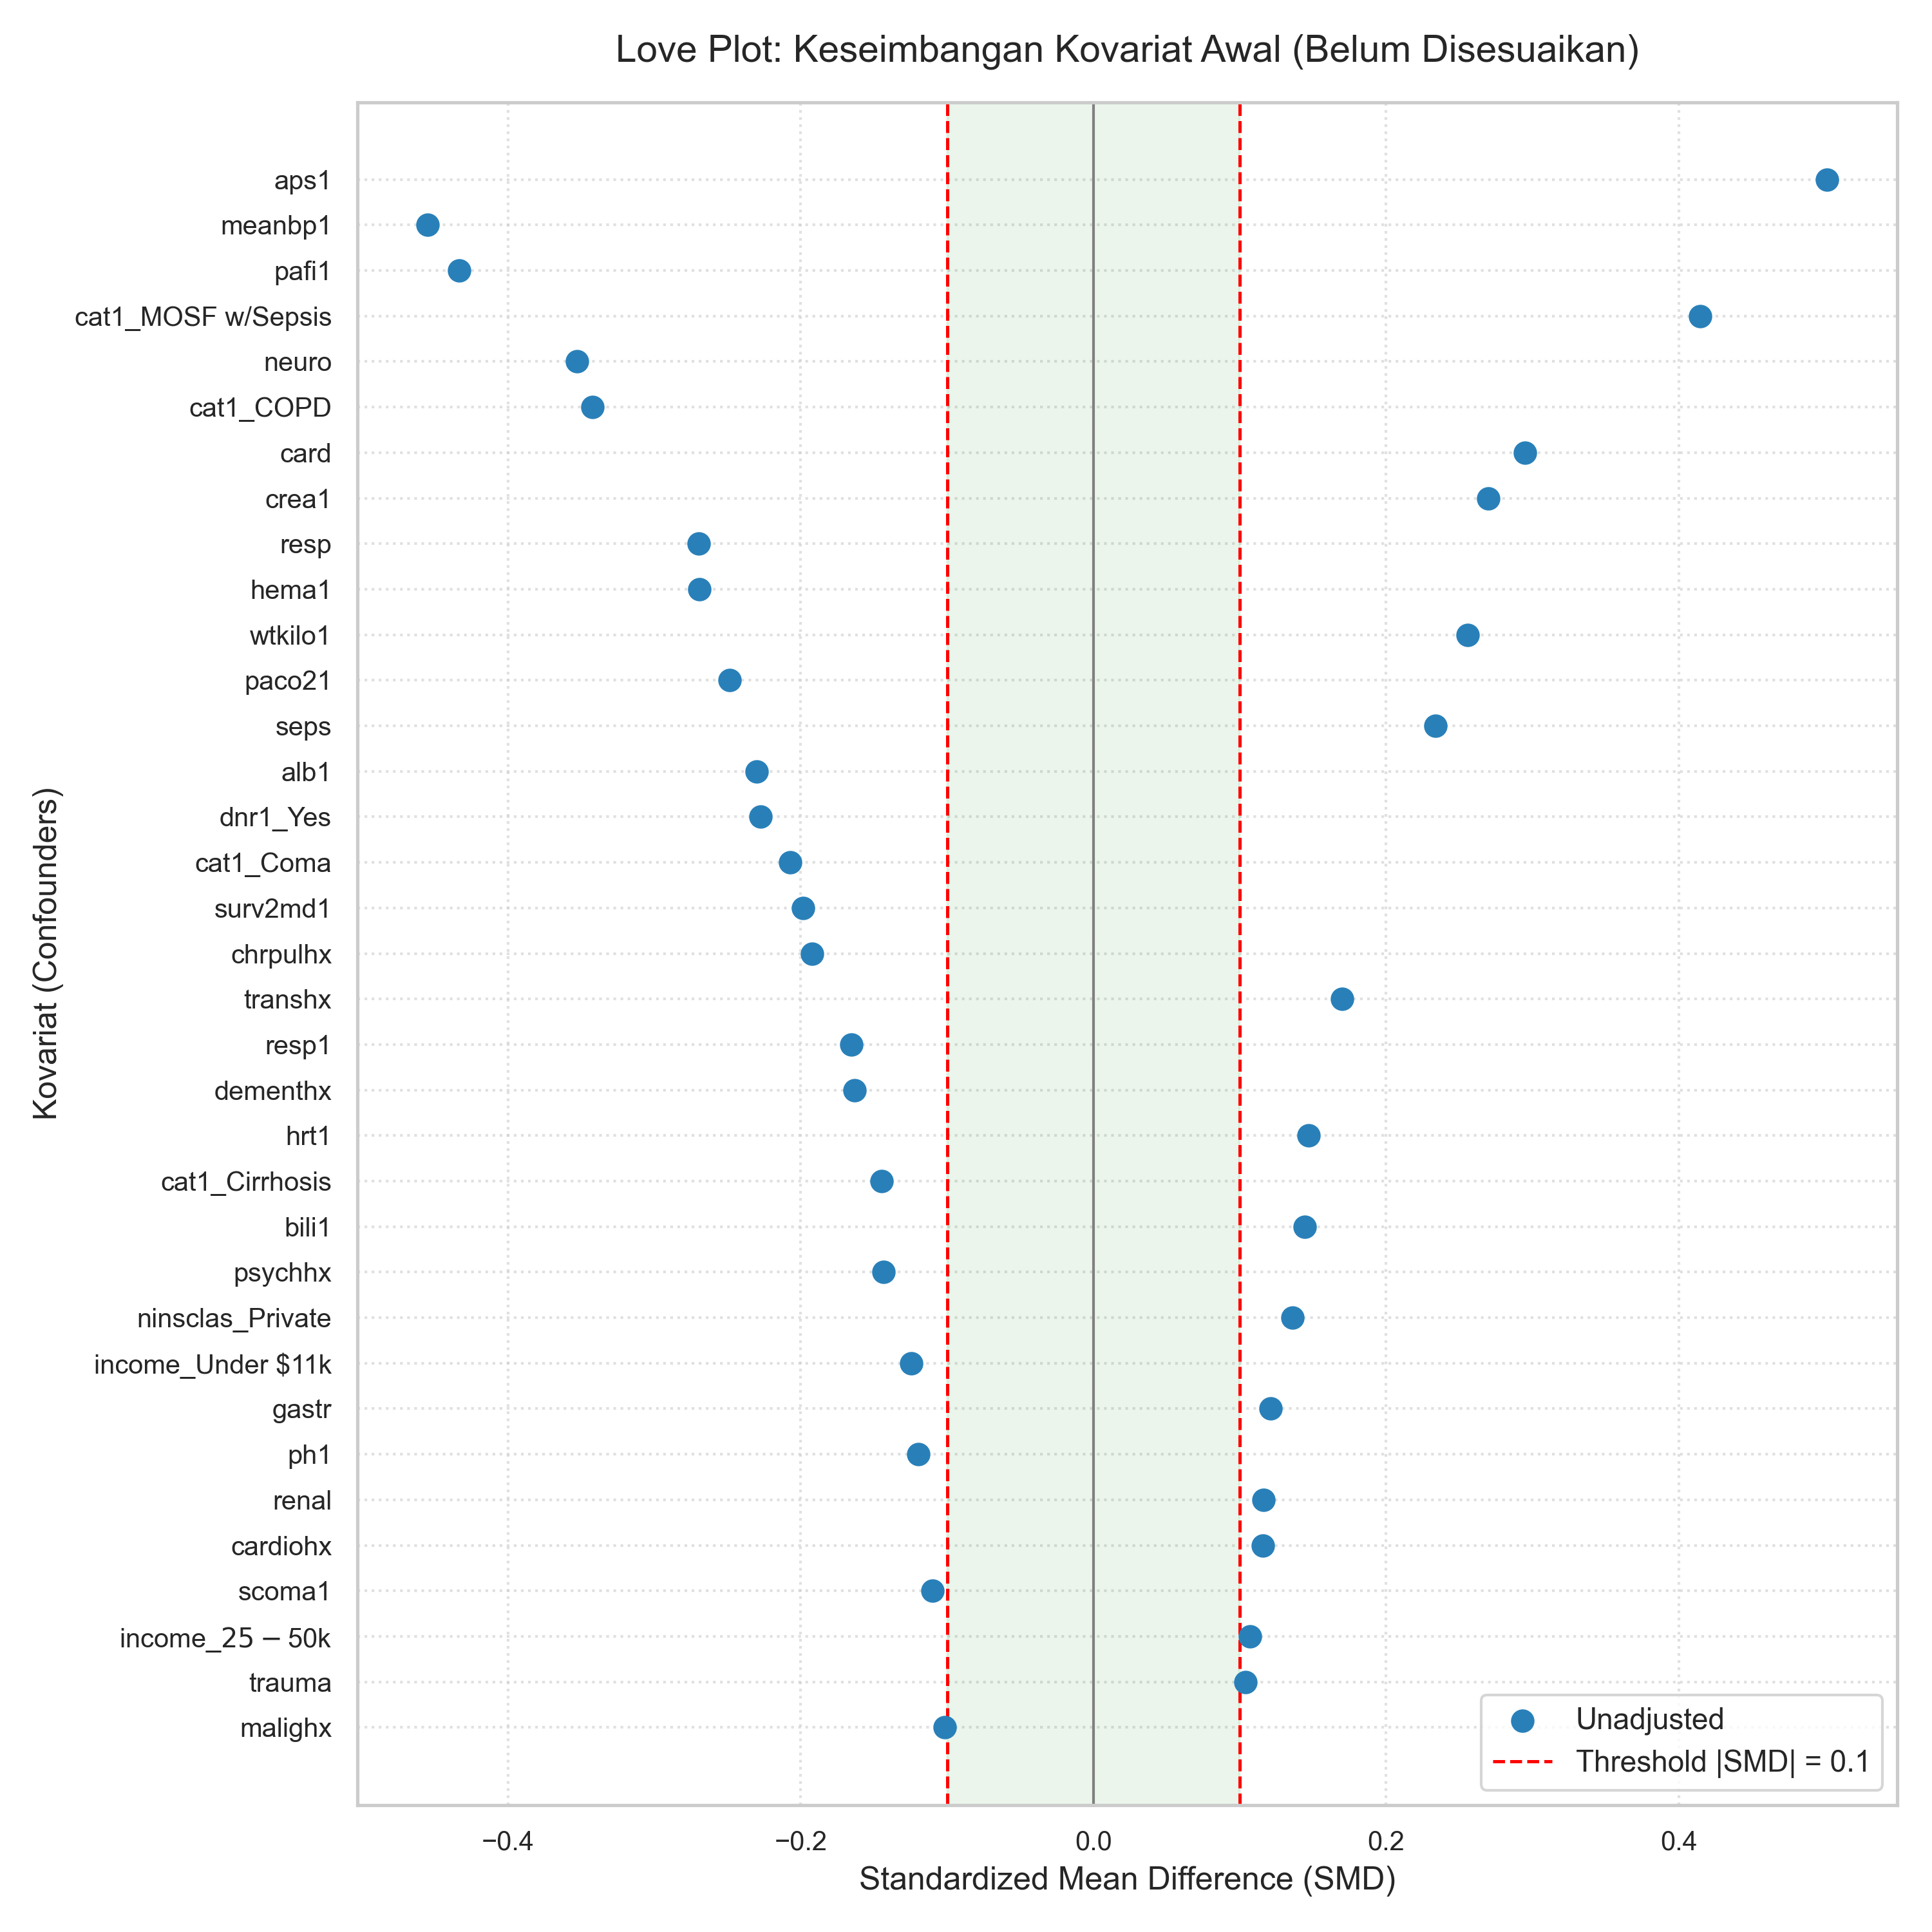

In [5]:
# Display figures inline
print("--- 1. Distribusi Treatment (RHC) ---")
display.display(display.Image(filename="../reports/figures/01_treatment_distribution.png"))

print("\n--- 2. Tingkat Mortalitas Naif (Outcome by Treatment) ---")
display.display(display.Image(filename="../reports/figures/02_outcome_by_treatment.png"))

print("\n--- 3. Love Plot (Covariate Balance Sebelum Penyesuaian) ---")
display.display(display.Image(filename="../reports/figures/03_love_plot_unadjusted.png"))


### Kesimpulan Awal EDA:
1. **Ketidakseimbangan Treatment:** Jumlah pasien kontrol (No RHC) sekitar 62%, sedangkan treatment (RHC) sekitar 38%.
2. **Korelasi Naif:** Pasien RHC memiliki mortalitas 30 hari sebesar **68.04%**, dibandingkan **62.97%** pada kontrol. Ini menghasilkan *risk difference* naif sebesar **+5.07%** (RHC tampak memperburuk kondisi pasien).
3. **Imbalance Kovariat Parah:** Love Plot menunjukkan banyak confounder penting (seperti `aps1` / APACHE III score, `meanbp1`, `pafi1`) memiliki nilai |SMD| jauh di atas threshold standar **0.1**. Ini menandakan adanya *selection bias / confounding by indication* di mana pasien yang menerima RHC memang jauh lebih sakit saat masuk ICU. Oleh karena itu, estimasi kausal formal (Fase 3) sangat diperlukan untuk menyesuaikan bias ini!
